### Combined 3-class instance segmentation

In [1]:
import numpy as np
import nibabel as nib
from scipy import ndimage as ndi
from scipy.spatial import KDTree
from skimage.segmentation import watershed
from skimage.measure import label, regionprops
from skimage.morphology import ball, opening, skeletonize, binary_dilation, binary_closing, binary_erosion, remove_small_objects
from skimage.feature import peak_local_max

def extract_canal_centerline(canal_mask, min_points=20):
    canal_mask = canal_mask.astype(bool)
    if canal_mask.sum() == 0:
        return None

    # 🔧 FIX: replace skeletonize_3d
    skeleton = skeletonize(canal_mask)
    points = np.column_stack(np.nonzero(skeleton))

    if len(points) < min_points:
        return None

    # Convert voxel → world coordinates
    # world = nib.affines.apply_affine(affine, points)

    # Superior–Inferior = largest Z in world space (RAS)
    start_idx = np.argmax(points[:, 2])

    ordered = [points[start_idx]]
    used = np.zeros(len(points), dtype=bool)
    used[start_idx] = True

    tree = KDTree(points)

    for _ in range(1, len(points)):
        last = ordered[-1]
        _, idxs = tree.query(last, k=10)
        for idx in idxs:
            if not used[idx]:
                ordered.append(points[idx])
                used[idx] = True
                break
        else:
            break

    return np.array(ordered)


def separate_vertebrae_watershed(vertebra_mask, min_size=500):
    """
    Separate fused vertebrae. Updated to use peak_local_max for better seed detection.
    """
    # Clean up noise
    vertebra_mask = opening(vertebra_mask.astype(bool), ball(1))
    
    # Distance map
    distance = ndi.distance_transform_edt(vertebra_mask)

    # Robust Seed Generation
    # min_distance=5 ensures seeds aren't too close (prevents over-segmentation)
    local_maxi = peak_local_max(distance, min_distance=5, labels=vertebra_mask)
    
    # Create marker mask
    markers = np.zeros_like(distance, dtype=int)
    for idx, point in enumerate(local_maxi):
        markers[tuple(point)] = idx + 1 # Unique ID for each seed
    
    # Watershed
    instances = watershed(-distance, markers, mask=vertebra_mask)

    # Filter small fragments
    cleaned = np.zeros_like(instances)
    new_id = 1
    for r in regionprops(instances):
        if r.area >= min_size:
            cleaned[instances == r.label] = new_id
            new_id += 1

    return cleaned


def separate_vertebrae_floodfill(vertebra_mask, min_body_size=300):
    """
    Separates vertebrae using 'Body Seeding' + 'Geodesic Flooding'.
    This ensures the 'Wings' are colored same as the 'Bodies' even if connected by thin pedicles.
    """
    # 1. Clean small noise
    mask_clean = remove_small_objects(vertebra_mask.astype(bool), min_size=100)
    
    # 2. FIND SEEDS: Aggressive Erosion
    # We shrink the bones until L1 breaks away from L2.
    # ball(3) is aggressive; if you lose small bones, try ball(2).
    eroded_mask = binary_erosion(mask_clean, ball(2)) 
    
    # 3. LABEL SEEDS
    markers = label(eroded_mask)
    
    # 4. FILTER SEEDS (Keep only the big main bodies)
    unique_labels, counts = np.unique(markers, return_counts=True)
    filtered_markers = np.zeros_like(markers)
    
    for lbl, count in zip(unique_labels, counts):
        if lbl == 0: continue
        if count >= min_body_size: # Filter out wings/noise, keep only bodies
            filtered_markers[markers == lbl] = lbl
            
    # Relabel seeds to be 1, 2, 3...
    filtered_markers, _ = label(filtered_markers, return_num=True)

    # 5. THE FIX: FLAT WATERSHED (Flood Fill)
    # Instead of using '-distance' (which creates hills/valleys), we use '0'.
    # This forces the algorithm to ignore thickness. 
    # The label simply flows to the nearest connected pixel.
    flat_map = np.zeros_like(mask_clean, dtype=float)
    
    final_labels = watershed(flat_map, filtered_markers, mask=mask_clean)
    
    return final_labels

def separate_vertebrae_nearest_neighbor(vertebra_mask, min_body_size=300):
    """
    Robust Separation using 'Nearest Neighbor' (Voronoi) logic.
    - Finds Body Centers (Magnets).
    - Assigns every disconnected fragment (wings, noise) to the nearest Body Center.
    - Fixes 'Floating Island' issues caused by broken pedicles.
    """
    # 1. Clean small noise (dust)
    mask_clean = remove_small_objects(vertebra_mask.astype(bool), min_size=100)
    
    # 2. FIND SEEDS: Aggressive Erosion to isolate Bodies
    # ball(2) is usually safe. If bodies merge, try ball(3).
    eroded_mask = binary_erosion(mask_clean, ball(2)) 
    
    # 3. LABEL SEEDS
    markers = label(eroded_mask)
    
    # 4. FILTER SEEDS (Keep only big bodies)
    unique_labels, counts = np.unique(markers, return_counts=True)
    filtered_markers = np.zeros_like(markers)
    
    for lbl, count in zip(unique_labels, counts):
        if lbl == 0: continue
        if count >= min_body_size: 
            filtered_markers[markers == lbl] = lbl
            
    # Relabel seeds (1, 2, 3...)
    filtered_markers, _ = label(filtered_markers, return_num=True)
    
    if filtered_markers.max() == 0:
        print("Warning: No vertebrae bodies found. Try decreasing min_body_size.")
        return mask_clean.astype(int) # Fallback

    # 5. THE FIX: NEAREST NEIGHBOR ASSIGNMENT
    # We ignore connectivity. We calculate the distance from every pixel 
    # to the nearest marker (Body Center).
    
    # 'indices' returns the index of the nearest seed pixel for every voxel in the image
    # The input to distance_transform_edt must be the BACKGROUND (inverted markers)
    # return_indices=True gives us the coordinates of the nearest foreground pixel
    dist, indices = ndi.distance_transform_edt(filtered_markers == 0, return_indices=True, return_distances=True)
    
    # Map the indices back to the labels
    # This creates a "Voronoi Diagram" filling the whole volume
    full_vol_labels = filtered_markers[tuple(indices)]
    
    # 6. MASKING
    # We now have a volume where empty space is also labeled. 
    # We cut it back to the original bone shape.
    final_labels = full_vol_labels * mask_clean
    
    return final_labels

def order_vertebrae(instances, centerline_points):
    """
    Assign labels.
    FIX: Uses offset to avoid collision with Disc/Canal classes.
    """
    props = regionprops(instances)
    if not props:
        return np.zeros_like(instances)

    # --- Sorting Logic ---
    if centerline_points is None:
        print("⚠ Canal missing — falling back to simple Z-sort")
        # Sort Top-to-Bottom (High Z to Low Z)
        rankings = [(r, r.centroid[2]) for r in props]
        rankings.sort(key=lambda x: x[1], reverse=True) 
        ordered = [x[0] for x in rankings]
    else:
        # Project onto curved centerline
        tree = KDTree(centerline_points.astype(np.float32))
        rankings = []
        for r in props:
            centroid = np.array(r.centroid)
            _, idx = tree.query(centroid) # idx = distance along the curve
            rankings.append((r, idx))
            
        # Sort by index on the centerline (0 = Top/Head)
        rankings.sort(key=lambda x: x[1])
        ordered = [r for r, _ in rankings]

    # --- Assignment Logic ---
    final = np.zeros_like(instances)
    
    # SPIDER Convention often separates Verts (1-20) and Discs (100+)
    # Let's assign strict IDs: L1=1, L2=2, L3=3...
    # Ensure these do NOT overlap with Canal/Disc in the merge step!
    for i, r in enumerate(ordered, start=1):
        if i > 25: break # Safety limit
        final[instances == r.label] = i 

    return final


def separate_vertebrae_disc_anchored(vertebra_mask, disc_mask, min_body_size=200):
    """
    Disc-Anchored Separation:
    1. Finds all bone clumps (Bodies + Wings).
    2. VALIDATES them: A clump is only a "Vertebra" if it touches a "Disc".
    3. Uses confirmed Bodies to claim the disconnected Wings.
    """
    # 1. Clean small noise
    mask_clean = remove_small_objects(vertebra_mask.astype(bool), min_size=100)
    
    # 2. Find Candidates (Erode to break connections)
    # We use ball(2) to separate L1 from L2.
    eroded_mask = binary_erosion(mask_clean, ball(2)) 
    
    # 3. Label all candidates (Bodies AND Wings currently exist here)
    markers = label(eroded_mask)
    
    # 4. PREPARE DISC MASK (The Anchor)
    # Dilate discs slightly to ensure they touch the bone seeds
    # (Just in case there is a 1-pixel gap in predictions)
    disc_expanded = binary_dilation(disc_mask > 0, ball(2))
    
    # 5. THE DISC CHECK (Filter Seeds)
    unique_labels = np.unique(markers)
    valid_markers = np.zeros_like(markers)
    
    # Loop through every "seed" the erosion found
    for lbl in unique_labels:
        if lbl == 0: continue
        
        # Extract this specific seed
        seed_loc = (markers == lbl)
        seed_size = np.sum(seed_loc)
        
        # Check 1: Is it big enough to be a bone?
        if seed_size < min_body_size:
            continue
            
        # Check 2: Does this seed physically touch a Disc?
        # We check if the overlap between this seed and the expanded disc mask is > 0
        overlap = np.logical_and(seed_loc, disc_expanded)
        
        if np.any(overlap):
            # PASSED: It touches a disc, so it's a Vertebral Body. Keep it.
            valid_markers[seed_loc] = lbl
        # FAILED: It doesn't touch a disc. It's a Wing. discard it.
            
    # Relabel confirmed seeds (1, 2, 3...)
    valid_markers, num_seeds = label(valid_markers, return_num=True)
    
    if num_seeds == 0:
        print("Warning: No seeds touched a disc. Falling back to size-only filter.")
        # Fallback: Just return the biggest blobs if disc check fails completely
        return separate_vertebrae_nearest_neighbor(vertebra_mask)

    # 6. NEAREST NEIGHBOR FILL (Voronoi)
    # Now valid_markers ONLY contains the Bodies.
    # We assign every pixel in the original mask to the nearest Body.
    dist, indices = ndi.distance_transform_edt(valid_markers == 0, return_indices=True, return_distances=True)
    full_vol_labels = valid_markers[tuple(indices)]
    
    final_labels = full_vol_labels * mask_clean
    
    return final_labels

def separate_vertebrae_watershed(vertebra_mask, min_body_size=300):
    """
    Separates vertebrae using Marker-Controlled Watershed.
    
    Why this is better for 'tails':
    - It treats the bone mask as a landscape.
    - It floods from the centers (seeds) OUTWARD.
    - It respects the bone boundaries, so it won't 'jump' across gaps 
      to steal the tail of the vertebra above.
    """
    # 1. Clean small noise
    mask_clean = remove_small_objects(vertebra_mask.astype(bool), min_size=100)
    
    # 2. FIND SEEDS (Same erosion logic as before)
    # Erode to disconnect the thin parts (pedicles/processes) and find the thick bodies
    eroded_mask = binary_erosion(mask_clean, ball(3)) 
    markers = label(eroded_mask)
    
    # 3. FILTER SEEDS (Keep only big bodies)
    unique_labels, counts = np.unique(markers, return_counts=True)
    filtered_markers = np.zeros_like(markers)
    
    for lbl, count in zip(unique_labels, counts):
        if lbl == 0: continue
        if count >= min_body_size: 
            filtered_markers[markers == lbl] = lbl
            
    # Relabel seeds sequentially (1, 2, 3...)
    filtered_markers, _ = label(filtered_markers, return_num=True)
    
    if filtered_markers.max() == 0:
        print("Warning: No seeds found. Returning raw mask.")
        return mask_clean.astype(np.uint16)

    # 4. THE FIX: WATERSHED
    # We create a "landscape" where the center of the bone is deep (valleys)
    # and the edges are high (peaks).
    # Euclidean Distance Transform: High values at center, 0 at edges.
    distance_map = ndi.distance_transform_edt(mask_clean)
    
    # We negate distance_map so peaks become valleys (basins) for Watershed
    # mask=mask_clean ensures we ONLY flood inside the bone
    labels = watershed(-distance_map, filtered_markers, mask=mask_clean)

    return labels

def separate_vertebrae_refined(vertebra_mask, min_body_size=300):
    """
    Hybrid Approach:
    1. Watershed: Separates connected bodies accurately.
    2. Z-Centroid Merging: Re-attaches disconnected 'floating' tails 
       to the body at the same vertical level.
    """
    # --- STEP 1: PREPARATION ---
    # Clean small noise (dust)
    mask_clean = remove_small_objects(vertebra_mask.astype(bool), min_size=50)
    
    # --- STEP 2: FIND & LABEL BODIES (SEEDS) ---
    # Aggressive erosion to find the thick vertebral bodies
    eroded_mask = binary_erosion(mask_clean, ball(2))
    markers = label(eroded_mask)
    
    # Filter seeds: Keep only large bodies
    unique_labels, counts = np.unique(markers, return_counts=True)
    body_markers = np.zeros_like(markers)
    
    active_labels = []
    for lbl, count in zip(unique_labels, counts):
        if lbl == 0: continue
        if count >= min_body_size:
            body_markers[markers == lbl] = lbl
            active_labels.append(lbl)
            
    # Relabel seeds sequentially (1, 2, 3...) to keep IDs clean
    body_markers, num_bodies = label(body_markers, return_num=True)
    
    if num_bodies == 0:
        return mask_clean.astype(np.uint16)

    # --- STEP 3: WATERSHED (The Core Separation) ---
    # Create the "landscape" for flooding
    distance_map = ndi.distance_transform_edt(mask_clean)
    # Flood from the bodies outward
    ws_labels = watershed(-distance_map, body_markers, mask=mask_clean)
    
    # --- STEP 4: IDENTIFY ORPHANS (The Fix) ---
    # Find pixels that are bone (mask_clean) but have no label (ws_labels == 0)
    # These are the disconnected tails/wings.
    orphan_mask = np.logical_and(mask_clean, ws_labels == 0)
    
    # Label the orphans so we can process each fragment individually
    orphan_labels, num_orphans = label(orphan_mask, return_num=True)
    
    if num_orphans == 0:
        return ws_labels # No disconnected parts found
        
    # --- STEP 5: Z-AXIS MERGING ---
    # We need the Center of Mass (Z-coordinate) for every Main Body
    body_props = regionprops(ws_labels)
    # Store as dictionary: {label_id: z_centroid}
    # Note: centroid is (x, y, z) or (z, y, x) depending on orientation.
    # Assuming standard Medical orientation (Z is usually axis 2 or 0). 
    # We will detect the "Long" axis as the Z axis.
    
    # Heuristic: The spine is longest along one axis. Let's find it.
    image_shape = vertebra_mask.shape
    z_axis = np.argmax(image_shape) # The axis with the most slices is usually Z
    
    body_z_coords = {}
    for p in body_props:
        body_z_coords[p.label] = p.centroid[z_axis]

    final_labels = ws_labels.copy()
    orphan_props = regionprops(orphan_labels)
    
    for orphan in orphan_props:
        o_z = orphan.centroid[z_axis]
        
        # Find the Body with the closest Z-coordinate
        best_match_id = -1
        min_z_dist = float('inf')
        
        for body_id, body_z in body_z_coords.items():
            z_dist = abs(o_z - body_z)
            if z_dist < min_z_dist:
                min_z_dist = z_dist
                best_match_id = body_id
        
        # Threshold: Only merge if reasonably close in Z (e.g., within 30 slices)
        # This prevents a random noise at the top from merging with the bottom.
        if best_match_id != -1 and min_z_dist < 50:
            # Assign this orphan fragment to the best matching body
            # orphan.coords gives coordinates of the fragment
            coords = orphan.coords
            final_labels[coords[:,0], coords[:,1], coords[:,2]] = best_match_id

    return final_labels

def separate_vertebrae_vertical_filtering(vertebra_mask, vertical_axis=2, min_body_size=300):
    """
    Nearest Neighbor separation with 'Vertical Conflict Suppression'.
    - Finds seeds via erosion.
    - If two seeds exist at the same vertical level (Z-slice), it deletes the smaller one.
    - Ensures Wings (smaller, same height) are merged into Bodies (larger).
    """
    # 1. Clean small noise
    mask_clean = remove_small_objects(vertebra_mask.astype(bool), min_size=100)
    
    # 2. Find Seeds (Aggressive Erosion)
    # ball(2) separates L1 from L2.
    eroded_mask = binary_erosion(mask_clean, ball(2)) 
    
    # 3. Label Initial Seeds
    markers = label(eroded_mask)
    
    # 4. FILTER: Vertical Conflict Suppression
    # We analyze every seed's position.
    props = regionprops(markers)
    
    # Store seeds as (label, size, z_centroid)
    seeds_info = []
    for p in props:
        if p.area < min_body_size: continue
        z_center = p.centroid[vertical_axis]
        seeds_info.append({
            'label': p.label,
            'size': p.area,
            'z': z_center
        })
    
    # Sort by size (largest first) so we always keep the main body
    seeds_info.sort(key=lambda x: x['size'], reverse=True)
    
    valid_labels = []
    # Threshold for "Same Level" collision (e.g., 10-15 slices)
    # If two seeds are within this Z-distance, they are fighting.
    z_conflict_threshold = 10.0 
    
    for seed in seeds_info:
        # Check if this seed conflicts with a larger seed we already kept
        is_conflict = False
        for kept_seed in valid_labels:
            z_diff = abs(seed['z'] - kept_seed['z'])
            if z_diff < z_conflict_threshold:
                # Collision! We already have a (larger) bone at this height.
                # This current seed must be a Wing or Fragment. Drop it.
                is_conflict = True
                break
        
        if not is_conflict:
            valid_labels.append(seed)

    # 5. Create the "Filtered Markers" map
    final_markers = np.zeros_like(markers)
    new_id = 1
    # Sort by Z (top to bottom) for nice sequential numbering (L1, L2, L3...)
    valid_labels.sort(key=lambda x: x['z']) 
    
    for seed in valid_labels:
        original_label = seed['label']
        final_markers[markers == original_label] = new_id
        new_id += 1

    if new_id == 1:
        print("Warning: All seeds filtered out. Returning raw mask.")
        return mask_clean.astype(int)

    # 6. NEAREST NEIGHBOR FILL (Voronoi)
    # The Body seeds (valid_labels) now claim the empty space (including wings)
    dist, indices = ndi.distance_transform_edt(final_markers == 0, return_indices=True, return_distances=True)
    full_vol_labels = final_markers[tuple(indices)]
    
    final_labels = full_vol_labels * mask_clean
    
    return final_labels

def separate_vertebrae_closing_fix(vertebra_mask, min_body_size=300):
    """
    Closing-Based Separation:
    1. Defines 'Seeds' from the original bodies.
    2. Creates a 'Bridge Mask' by closing gaps (connecting floating tails).
    3. Runs Watershed on the Bridge Mask.
    4. Maps the result back to the Original Mask.
    """
    # 1. CLEANING
    # Remove tiny dust, but keep the tails (even if they are size ~100)
    mask_clean = remove_small_objects(vertebra_mask.astype(bool), min_size=50)
    
    # 2. FIND SEEDS (The 'Magnets')
    # We erode the ORIGINAL clean mask to find the hard centers of the bones.
    # These seeds are guaranteed to be separate.
    eroded_mask = binary_erosion(mask_clean, ball(2)) 
    markers = label(eroded_mask)
    
    # Filter seeds to keep only big bodies
    unique_labels, counts = np.unique(markers, return_counts=True)
    filtered_markers = np.zeros_like(markers)
    for lbl, count in zip(unique_labels, counts):
        if lbl == 0: continue
        if count >= min_body_size:
            filtered_markers[markers == lbl] = lbl
            
    # Relabel seeds (1, 2, 3...)
    filtered_markers, _ = label(filtered_markers, return_num=True)
    
    if filtered_markers.max() == 0:
        print("Warning: No seeds found. Returning raw mask.")
        return mask_clean.astype(np.uint16)

    # 3. CREATE THE "BRIDGE MASK" (The Key Fix)
    # We use binary_closing to close small gaps.
    # ball(3) creates a bridge of ~3-5 pixels. Increase to ball(4) if gaps are huge.
    # This temporarily connects the "floating tail" to the "body".
    bridge_mask = binary_closing(mask_clean, ball(3))
    
    # 4. WATERSHED ON THE BRIDGE
    # We run watershed on the BRIDGE mask, not the original.
    # The seeds (from step 2) will grow and flow across the bridges to claim the tails.
    # If L1 and L2 touch in the bridge mask, Watershed will draw a line between them.
    distance_map = ndi.distance_transform_edt(bridge_mask)
    bridge_labels = watershed(-distance_map, filtered_markers, mask=bridge_mask)
    
    # 5. CUT BACK TO ORIGINAL SHAPE
    # We now have labels for the floating parts (because they were bridged).
    # We simply multiply by the original mask to remove the artificial bridges.
    final_labels = bridge_labels * mask_clean
    
    return final_labels.astype(np.uint16)

def postprocess_spider_case(nifti_in, nifti_out):
    """
    Merges everything safely.
    Schema:
      0: Background
      1-25: Vertebrae (L1=1, L2=2...)
      200: Intervertebral Discs (Merged class)
      100: Spinal Canal
    """
    img = nib.load(nifti_in)
    pred = img.get_fdata().astype(np.uint8)

    # Semantic masks from nnU-Net
    vertebra_mask = (pred == 1)
    # IVD mask (Class 2)
    ivd_mask = (pred == 2)
    # Canal mask (Class 3)
    canal_mask = (pred == 3)

    print(f"Processing: {nifti_in}")

    # 1. Get Canal Centerline
    centerline = extract_canal_centerline(canal_mask)

    # 2. Watershed
    # vertebra_instances = separate_vertebrae_disc_anchored(vertebra_mask, ivd_mask, min_body_size=200)
    # vertebra_instances = separate_vertebrae_nearest_neighbor(vertebra_mask)
    vertebra_instances = separate_vertebrae_watershed(vertebra_mask)

    # vertebra_instances = separate_vertebrae_refined(vertebra_mask)

    # 3. Geometric Ordering
    ordered_vertebrae = order_vertebrae(vertebra_instances, centerline)

    # 4. Safe Merge
    final = np.zeros_like(pred, dtype=np.uint16)
    
    # Place Discs (ID 200)
    final[ivd_mask] = 200 
    
    # Place Canal (ID 100)
    final[canal_mask] = 100
    
    # Place Vertebrae (IDs 1, 2, 3...)
    # We overwrite disc/canal if they overlap, or use 'where' to preserve them
    # Usually bone > disc priority
    vert_mask = (ordered_vertebrae > 0)
    final[vert_mask] = ordered_vertebrae[vert_mask]

    out_img = nib.Nifti1Image(final, img.affine, img.header)
    nib.save(out_img, nifti_out)
    print(f"Saved: {nifti_out}")

if __name__ == "__main__":
    # Test logic
    input_pred = "../nnUNet_preprocessed/Dataset500_Spider/gt_segmentations/Spider_004.nii.gz"
    # input_pred = "../odd-even-strategy/predictions/242_pred_3class.nii.gz"
    output_labeled = "Spider_003_final3.nii.gz"

    postprocess_spider_case(input_pred, output_labeled)
    pass

Processing: ../nnUNet_preprocessed/Dataset500_Spider/gt_segmentations/Spider_004.nii.gz
Saved: Spider_003_final3.nii.gz


Visualization functions

In [7]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def create_random_colormap(num_classes):
    # Create bright distinct colors
    colors = plt.cm.hsv(np.linspace(0, 1, num_classes))
    np.random.seed(42)
    np.random.shuffle(colors)
    colors[0] = [0, 0, 0, 1] # Background is Black
    return ListedColormap(colors)

def visualize_mip(file_path):
    if not os.path.exists(file_path):
        print(f"Error: {file_path} not found.")
        return

    print(f"Loading {file_path}...")
    nii = nib.load(file_path)
    data = nii.get_fdata().astype(int)

    # Check labels
    unique_ids = np.unique(data)
    print(f"Labels found: {unique_ids}")

    # --- MAXIMUM INTENSITY PROJECTION (MIP) ---
    # We take the maximum value along each axis.
    # This flattens the 3D volume so we see EVERYTHING.
    # Note: Because labels are integers (1,2,3...), 'max' might favor higher numbers 
    # if they overlap in the view, but for separated bones, it works great.
    
    print("Generating projections...")
    
    # Sagittal MIP (Side view) - Flatten X axis
    # We ignore 0 (background) to keep colors clean
    mip_sagittal = np.max(data, axis=0)
    
    # Coronal MIP (Front view) - Flatten Y axis
    mip_coronal = np.max(data, axis=1)
    
    # Axial MIP (Top view) - Flatten Z axis
    # (Optional: Axial MIP is often messy, so we might just take a middle chunk)
    mip_axial = np.max(data, axis=2)

    # Rotate them to stand upright
    mip_sagittal = np.rot90(mip_sagittal)
    mip_coronal = np.rot90(mip_coronal)
    mip_axial = np.rot90(mip_axial)

    # --- PLOT ---
    max_id = np.max(unique_ids)
    cmap = create_random_colormap(max_id + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    plt.style.use('dark_background')

    axes[0].imshow(mip_sagittal, cmap=cmap, interpolation='nearest')
    axes[0].set_title("Sagittal Projection (Side)")
    axes[0].axis('off')

    axes[1].imshow(mip_coronal, cmap=cmap, interpolation='nearest')
    axes[1].set_title("Coronal Projection (Front)")
    axes[1].axis('off')
    
    axes[2].imshow(mip_axial, cmap=cmap, interpolation='nearest')
    axes[2].set_title("Axial Projection (Top-Down)")
    axes[2].axis('off')

    plt.tight_layout()
    print("Displaying Image...")
    plt.show()

def visualize_3_views(file_path):
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return

    print(f"Loading {file_path}...")
    nii = nib.load(file_path)
    data = nii.get_fdata().astype(int)

    # 1. FIND THE CENTER OF THE SPINE
    # We don't want to plot empty space. We find the center of mass of the mask.
    if np.sum(data) == 0:
        print("Mask is empty! Nothing to visualize.")
        return
        
    print("Calculating best slices...")
    # Get center coordinates of all non-zero pixels
    center = ndi.center_of_mass(data > 0)
    cx, cy, cz = int(center[0]), int(center[1]), int(center[2])

    # 2. EXTRACT SLICES (Orthogonal Views)
    # Orientation depends on your NIfTI, but standard is (X, Y, Z)
    # We rotate them 90 degrees so they look "upright" in Matplotlib
    
    # Sagittal View (Side) - Slice along X
    slice_sagittal = np.rot90(data[cx, :, :])
    
    # Coronal View (Front) - Slice along Y
    slice_coronal = np.rot90(data[:, cy, :])
    
    # Axial View (Top-Down) - Slice along Z
    slice_axial = np.rot90(data[:, :, cz])

    # 3. PREPARE COLORMAP
    # Get max label ID to size the colormap correctly
    max_id = np.max(data)
    cmap = create_random_colormap(max_id + 1)

    # 4. PLOT
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    plt.style.use('dark_background') # Looks better for medical masks

    # Sagittal
    axes[0].imshow(slice_sagittal, cmap=cmap, interpolation='nearest')
    axes[0].set_title(f"Sagittal View (x={cx})")
    axes[0].axis('off')

    # Coronal
    axes[1].imshow(slice_coronal, cmap=cmap, interpolation='nearest')
    axes[1].set_title(f"Coronal View (y={cy})")
    axes[1].axis('off')

    # Axial
    axes[2].imshow(slice_axial, cmap=cmap, interpolation='nearest')
    axes[2].set_title(f"Axial View (z={cz})")
    axes[2].axis('off')

    plt.tight_layout()
    
    # Show on screen
    print("Displaying plot...")
    plt.show()

Loading ./Spider_003_final3.nii.gz...
Labels found: [  0   1   2   3   4   5   6 100 200]
Generating projections...
Displaying Image...


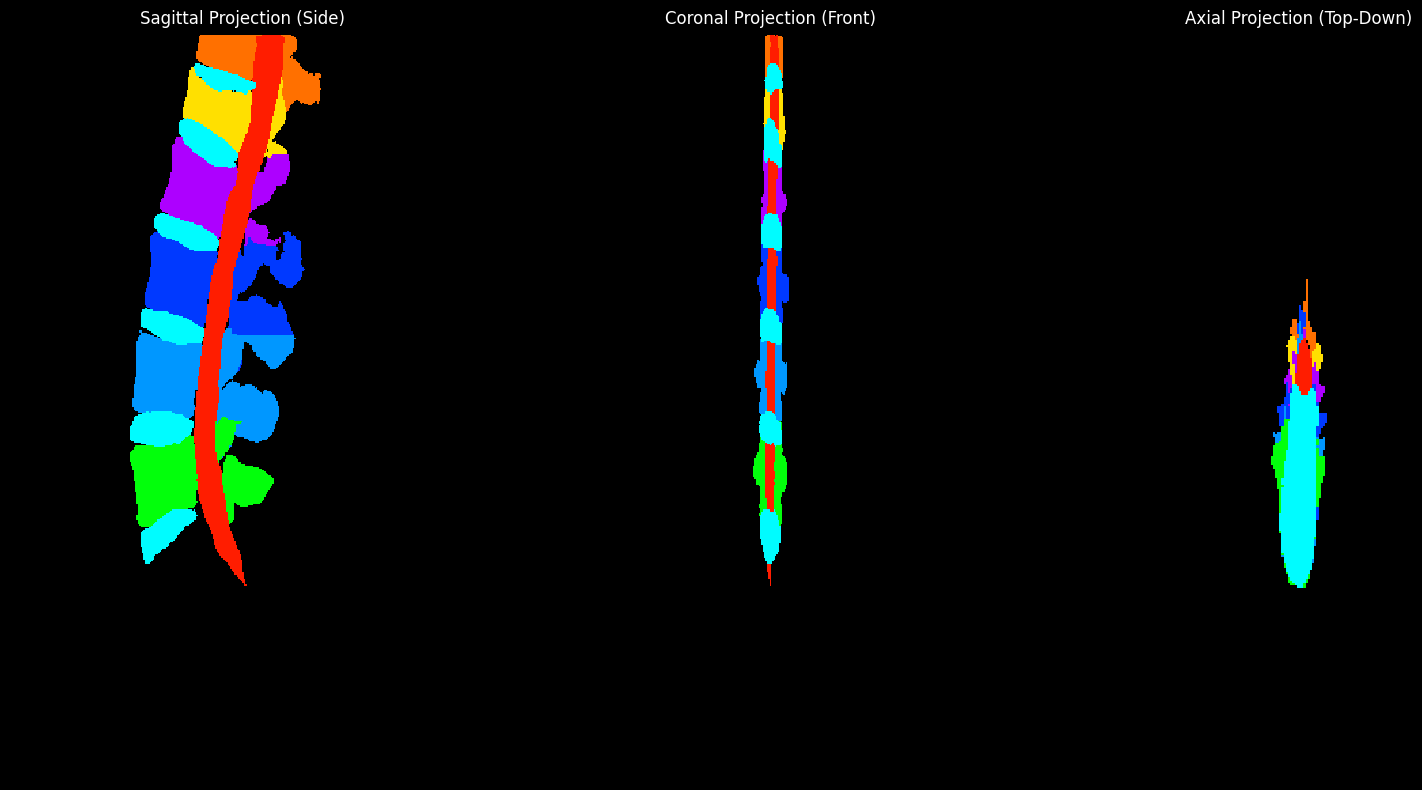

Loading ./Spider_003_final3.nii.gz...
Calculating best slices...
Displaying plot...


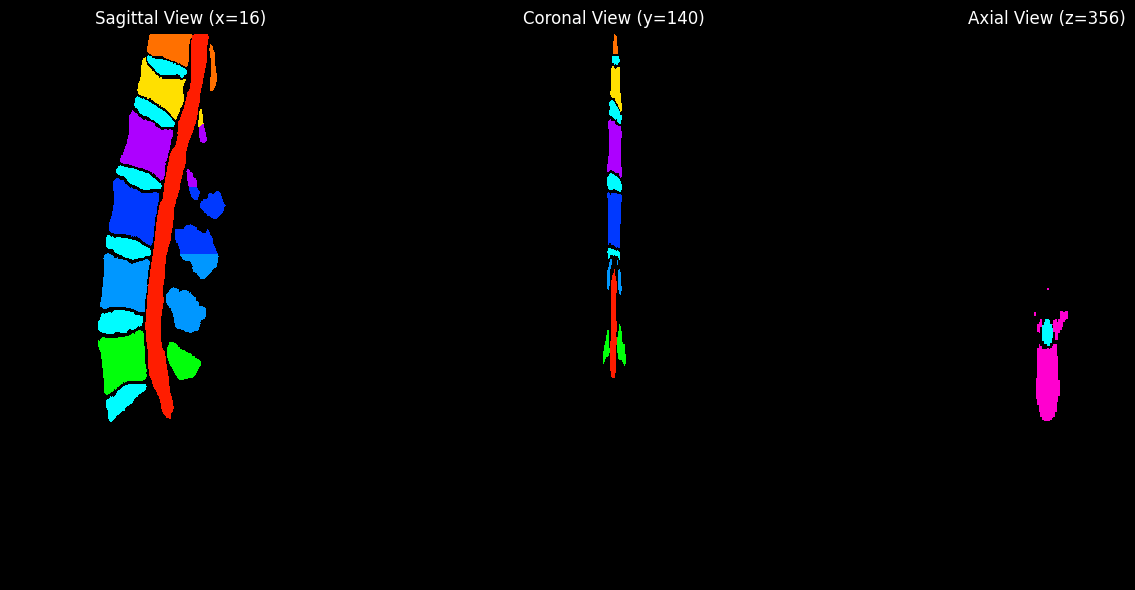

In [8]:
visualize_mip("./Spider_003_final3.nii.gz")
visualize_3_views("./Spider_003_final3.nii.gz")

### odd-even 4-class instance segmentation

Shape: (162, 533, 178)
Labels: [0 1 2 3 4]
   > Found 12 Odd Vertebra blobs
   > Found 14 Even Vertebra blobs
Output file saved to:  ../odd-even-strategy/predictions/242_pred_instance.nii.gz


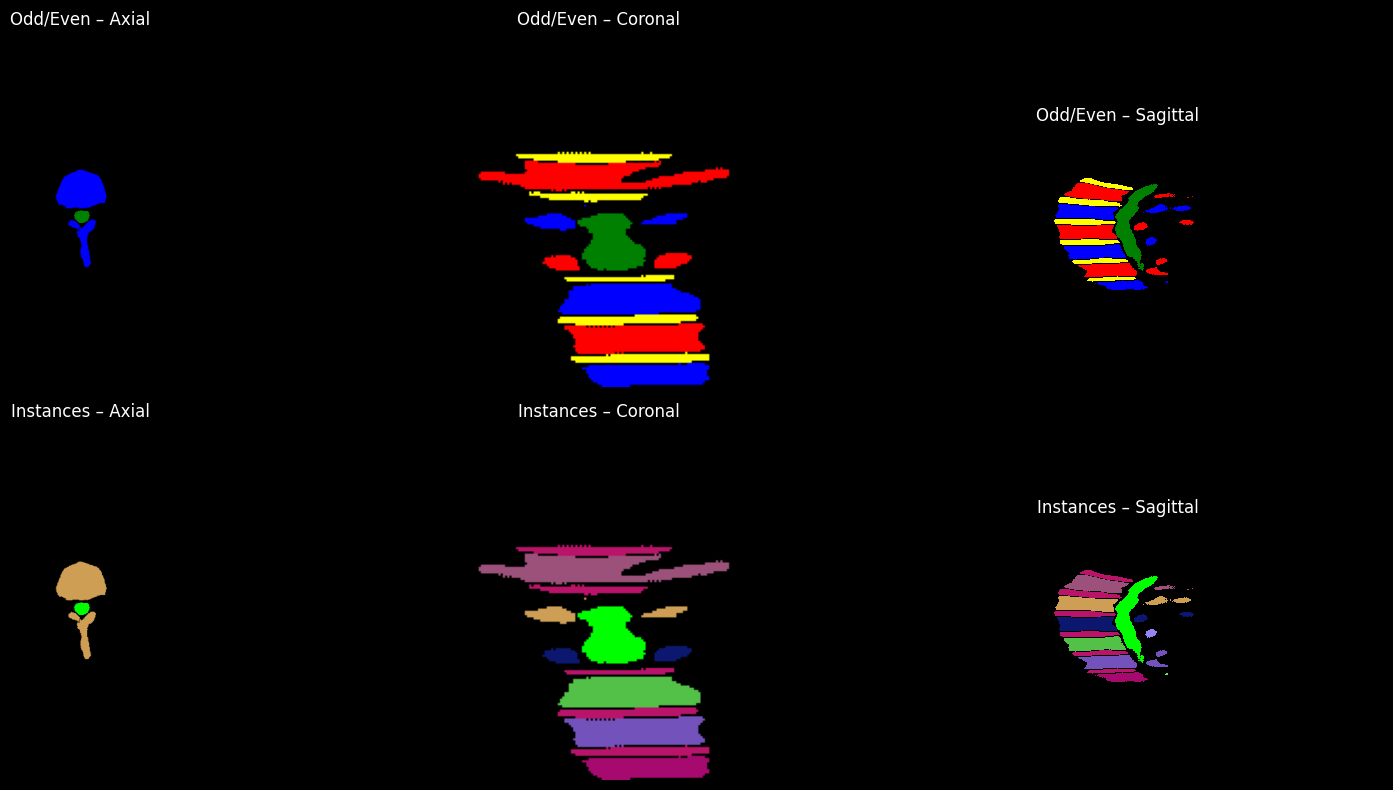

In [9]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, center_of_mass
from matplotlib.colors import ListedColormap
import random

# -----------------------------
# INSTANCE LOGIC (YOUR METHOD)
# -----------------------------
def get_blobs_info(binary_mask, class_name):
    labeled_vol, num = label(binary_mask, structure=np.ones((3,3,3)))
    print(f"   > Found {num} {class_name} blobs")

    if num == 0:
        return []

    centroids = center_of_mass(binary_mask, labeled_vol, range(1, num + 1))

    blobs = []
    for i, cent in enumerate(centroids):
        blobs.append({
            "z": cent[2],                 # Z-axis height
            "mask": labeled_vol == (i+1),
            "type": class_name
        })
    return blobs


def vertebra_instance_labeling(lbl):
    """
    Instance labeling using ODD/EVEN separation (correct logic)
    """
    inst = np.zeros_like(lbl, dtype=np.uint16)

    # Separate odd & even (they never touch)
    blobs_odd  = get_blobs_info(lbl == 1, "Odd Vertebra")
    blobs_even = get_blobs_info(lbl == 2, "Even Vertebra")

    all_blobs = blobs_odd + blobs_even

    # Sort head → feet (reverse if needed)
    all_blobs.sort(key=lambda x: x["z"], reverse=True)

    print("   > Total vertebrae:", len(all_blobs))

    current_id = 1
    for blob in all_blobs:
        inst[blob["mask"]] = current_id
        current_id += 1

    return inst

def vertebra_instance_labeling_with_semantics(lbl):
    inst = np.zeros_like(lbl, dtype=np.uint16)

    blobs_odd  = get_blobs_info(lbl == 1, "Odd Vertebra")
    blobs_even = get_blobs_info(lbl == 2, "Even Vertebra")

    all_blobs = blobs_odd + blobs_even
    all_blobs.sort(key=lambda x: x["z"], reverse=True)

    current_id = 1
    for blob in all_blobs:
        inst[blob["mask"]] = current_id
        current_id += 1

    # ---- ADD SEMANTIC OVERLAYS ----
    inst[lbl == 3] = 200   # Discs
    inst[lbl == 4] = 255   # Canal

    return inst



# -----------------------------
# VISUALIZATION
# -----------------------------
def displayLabels(path, out_path):
    LABEL_PATH = path

    nii = nib.load(LABEL_PATH)
    lbl = nii.get_fdata().astype(np.uint8)

    print("Shape:", lbl.shape)
    print("Labels:", np.unique(lbl))

    inst_lbl = vertebra_instance_labeling_with_semantics(lbl)

    # Create new NIfTI image
    inst_nii = nib.Nifti1Image(
        inst_lbl.astype(np.uint16),  # use uint16 if you have many instances
        affine=nii.affine,
        header=nii.header
    )

    # Optional: update datatype in header explicitly
    inst_nii.set_data_dtype(np.uint16)

    # Save as .nii.gz
    nib.save(inst_nii, out_path)

    print("Output file saved to: ", out_path)

    # Center slices
    z = lbl.shape[0] // 2
    y = lbl.shape[1] // 2
    x = lbl.shape[2] // 2

    # ---- Colormaps ----
    five_class_cmap = ListedColormap([
        "black",   # 0 background
        "red",     # 1 odd
        "blue",    # 2 even
        "yellow",  # 3 disc
        "green"    # 4 canal
    ])

    # Random instance colors
    n_inst = inst_lbl.max()
    colors = [(0,0,0)] + [
        (random.random(), random.random(), random.random())
        for _ in range(n_inst)
    ]

    colors.append((1.0, 1.0, 0.0))  # 200 → Disc (Yellow)
    colors.append((0.0, 1.0, 0.0))  # 255 → Canal (Green)

    inst_cmap = ListedColormap(colors)

    # ---- Plot ----
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # Row 1 – Odd/Even mask
    axes[0,0].imshow(lbl[z,:,:], cmap=five_class_cmap, vmin=0, vmax=4)
    axes[0,0].set_title("Odd/Even – Axial")

    axes[0,1].imshow(lbl[:,y,:], cmap=five_class_cmap, vmin=0, vmax=4)
    axes[0,1].set_title("Odd/Even – Coronal")

    axes[0,2].imshow(lbl[:,:,x], cmap=five_class_cmap, vmin=0, vmax=4)
    axes[0,2].set_title("Odd/Even – Sagittal")

    # Row 2 – Instance labels
    axes[1,0].imshow(inst_lbl[z,:,:], cmap=inst_cmap)
    axes[1,0].set_title("Instances – Axial")

    axes[1,1].imshow(inst_lbl[:,y,:], cmap=inst_cmap)
    axes[1,1].set_title("Instances – Coronal")

    axes[1,2].imshow(inst_lbl[:,:,x], cmap=inst_cmap)
    axes[1,2].set_title("Instances – Sagittal")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

path = "../odd-even-strategy/predictions/242_pred_4class.nii.gz"
out_path="../odd-even-strategy/predictions/242_pred_instance.nii.gz"
displayLabels(path, out_path)

Some more post-processing required

- Remove small segmentations